# Objective
To analyze sales performance across different regions to identify high-performing and low-performing areas, understand revenue and profit trends, and provide insights to improve regional sales strategy and decision-making.




In [181]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 

In [246]:
sheet = pd.read_excel("Regional Sales.xlsx", sheet_name=None)

In [438]:
sales = sheet["Sales Orders"]
customer = sheet["Customers"]
state = sheet["State Regions"]
region = sheet["Regions"]
budget = sheet["2024 Budget"]



In [439]:
state_cols = state.iloc[0]

In [440]:
state.columns = state_cols

In [441]:
state = state.iloc[1:]

In [442]:
sales.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Product name', 'Order Quantity',
       'Unit Price', 'Line Total', 'Total Unit Cost', 'Budget'],
      dtype='object')

In [443]:
customer.columns

Index(['Customer Index', 'Customer Names'], dtype='object')

In [444]:
state.columns

Index(['State Code', 'State', 'Region'], dtype='object', name=0)

In [445]:
region.columns

Index(['id', 'name', 'county', 'state_code', 'state', 'type', 'latitude',
       'longitude', 'area_code', 'population', 'households', 'median_income',
       'land_area', 'water_area', 'time_zone'],
      dtype='object')

In [446]:
budget.columns

Index(['Product Name', '2024 Budgets'], dtype='object')

## Merging sales with others

In [447]:
df = sales.merge(customer, left_on='Customer Name Index', right_on='Customer Index', how='left') 
          

In [448]:
df1 = region.merge(state, left_on='state_code', right_on='State Code', how='left')

In [449]:
df = df.merge(df1, left_on='Delivery Region Index', right_on='id', how='left')

In [450]:
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Product name', 'Order Quantity',
       'Unit Price', 'Line Total', 'Total Unit Cost', 'Budget',
       'Customer Index', 'Customer Names', 'id', 'name', 'county',
       'state_code', 'state', 'type', 'latitude', 'longitude', 'area_code',
       'population', 'households', 'median_income', 'land_area', 'water_area',
       'time_zone', 'State Code', 'State', 'Region'],
      dtype='object')

In [453]:
df = df.drop(columns="State")

In [454]:
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Product name', 'Order Quantity',
       'Unit Price', 'Line Total', 'Total Unit Cost', 'Budget',
       'Customer Index', 'Customer Names', 'id', 'name', 'county',
       'state_code', 'state', 'type', 'latitude', 'longitude', 'area_code',
       'population', 'households', 'median_income', 'land_area', 'water_area',
       'time_zone', 'State Code', 'Region'],
      dtype='object')

In [455]:
df.columns = df.columns.str.lower()

In [456]:
cols_to_keep = ['ordernumber', 'orderdate','customer names', 'channel','product name', 'order quantity',
       'unit price', 'line total', 'total unit cost', 'county', 'state_code', 'state','region','budget'
               ]
    

In [457]:
df = df[cols_to_keep]

In [458]:
df

,ordernumber,orderdate,customer names,channel,product name,order quantity,unit price,line total,total unit cost,county,state_code,state,region,budget
0,SO - 000225,2022-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,Chatham County,GA,Georgia,South,964940.231
1,SO - 0003378,2022-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,Johnson County,IN,Indiana,Midwest,2067108.120
2,SO - 0005126,2022-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,Alameda County,CA,California,West,5685138.270
3,SO - 0005614,2022-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,Monroe County,IN,Indiana,Midwest,889737.555
4,SO - 0005781,2022-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,Hartford County,CT,Connecticut,Northeast,1085037.329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2025-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.7,21788.4,980.478,Bucks County,PA,Pennsylvania,Northeast,5685138.270
64100,SO - 0007706,2025-02-28,Yombu Corp,Export,Product 21,6,864.3,5185.8,579.081,Cook County,IL,Illinois,Midwest,959899.218
64101,SO - 0007718,2025-02-28,Bath Group,Distributor,Product 13,11,3953.0,43483.0,2648.510,Broward County,FL,Florida,South,3720639.645
64102,SO - 0008084,2025-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.7,27717.9,2930.178,Erie County,NY,New York,Northeast,2067108.120


In [459]:
df.isnull().sum()

ordernumber        0
orderdate          0
customer names     0
channel            0
product name       0
order quantity     0
unit price         0
line total         0
total unit cost    0
county             0
state_code         0
state              0
region             0
budget             0
dtype: int64

## Choosing columns only dated year is 2024


In [460]:
df = df[df.loc[:, 'orderdate'].dt.year == 2024]

## Sales Analysis

In [487]:
# Total unit price 
df2 = df.copy()
df2["total_cost"] = df2["total unit cost"] * df2["order quantity"]

In [488]:
df2.columns

Index(['ordernumber', 'orderdate', 'customer names', 'channel', 'product name',
       'order quantity', 'unit price', 'line total', 'total unit cost',
       'county', 'state_code', 'state', 'region', 'budget', 'total_cost'],
      dtype='object')

In [489]:
df2["profit"] =  df2["line total"] - df2["total_cost"]

In [490]:
df2["profit_margin"] = df2["profit"]/df2['line total']

In [491]:
df_profit = {
    "Total cost":df2["total_cost"].sum().round(),
    "Revenue":df2["line total"].sum().round(),
    
    "Profit":df2["profit"].sum().round(),
}

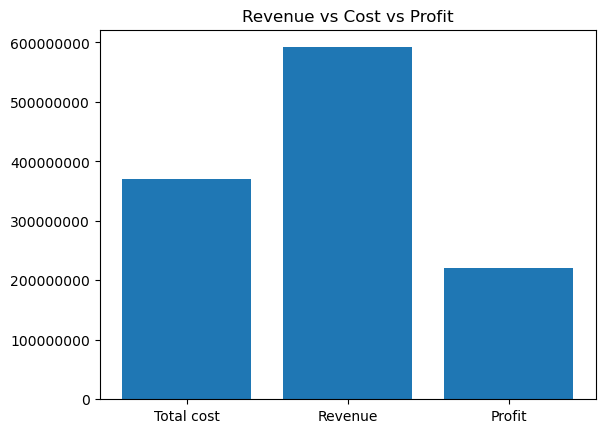

In [492]:
plt.bar(df_profit.keys(), df_profit.values())
plt.title("Revenue vs Cost vs Profit")
plt.ticklabel_format(style='plain', axis='y')


## Time Analysis

### Sales by month

In [493]:
df2["orderdate_time"] = pd.to_datetime(df2.orderdate)

In [494]:
df2["month"] = df2.orderdate_time.dt.month_name()
df2["month_no"] = df2.orderdate_time.dt.month

In [495]:
df_month_sales = (
    df2.groupby(["month_no", "month"])["line total"]
        .sum()
        .reset_index()
        .sort_values("month_no")
        .set_index("month_no")
        .rename(columns={"line total": "Revenue_by_month"})
)

In [496]:
df_month_sales

,month,Revenue_by_month
month_no,,
1,January,48880030.9
2,February,44392833.2
3,March,52543671.3
4,April,46627155.9
5,May,51614046.3
6,June,48565506.1
7,July,48885009.0
8,August,50383162.5
9,September,49310217.8


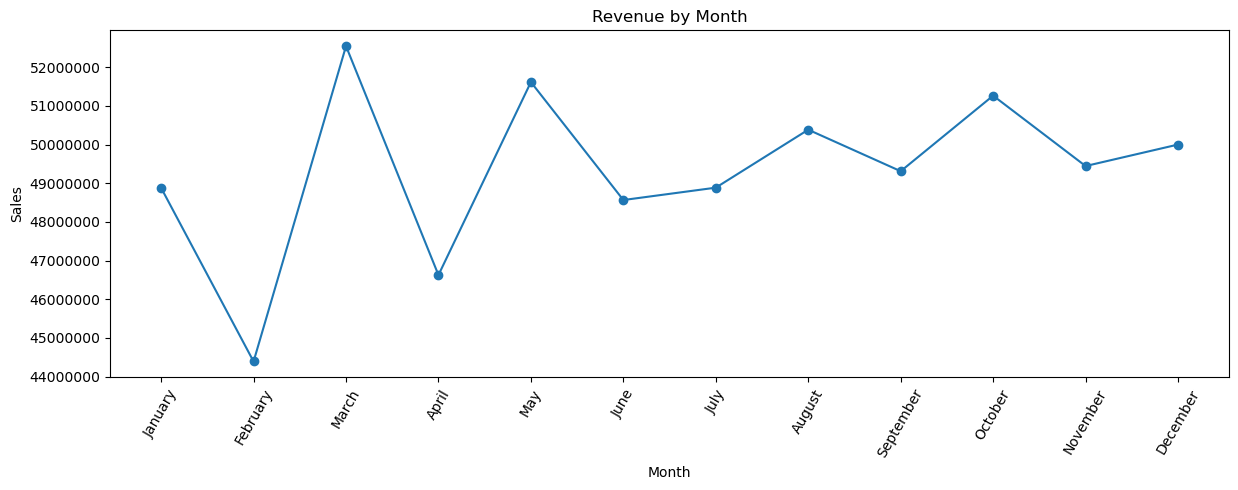

In [497]:

plt.figure(figsize=(12,5))  # more horizontal

plt.plot(df_month_sales["month"],
         df_month_sales["Revenue_by_month"],
         marker="o")

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Revenue by Month")

plt.xticks(rotation=60)
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')

plt.show()

In [498]:
df_profit_month = (
    df2.groupby(["month_no", "month"])["profit"]
       .sum()
       .reset_index()
       .sort_values("month_no")
        .set_index("month_no")
        .rename(columns={"profit": "profit_by_month"})
)

In [499]:
df_profit_month

,month,profit_by_month
month_no,,
1,January,1.855090e+07
2,February,1.675815e+07
3,March,1.949165e+07
4,April,1.731370e+07
5,May,1.935044e+07
6,June,1.788840e+07
7,July,1.814834e+07
8,August,1.851738e+07
9,September,1.833646e+07


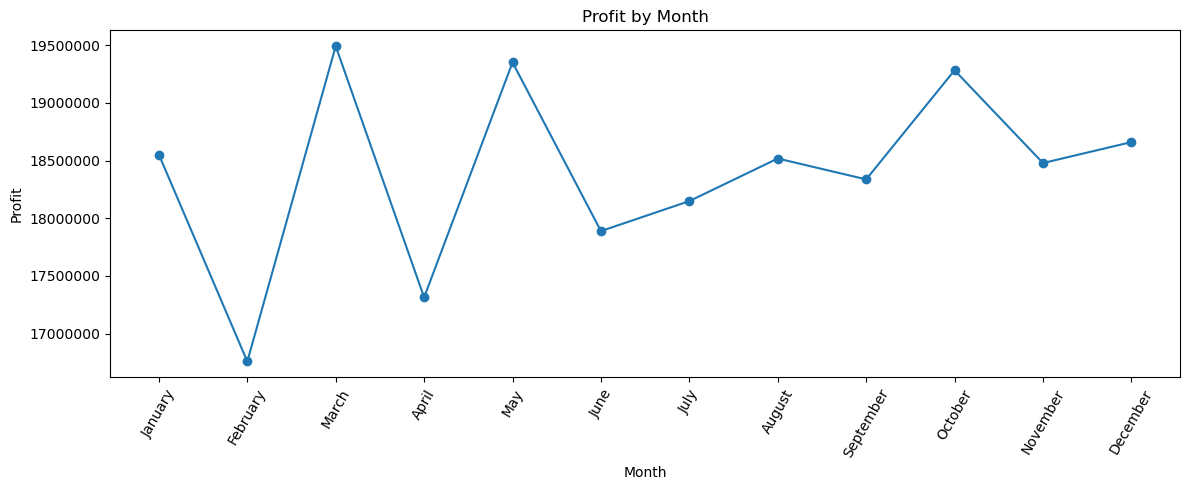

In [500]:
plt.figure(figsize=(12,5))
plt.plot(df_profit_month["month"], df_profit_month["profit_by_month"], marker="o")

plt.xlabel("Month")
plt.ylabel("Profit")
plt.title("Profit by Month")
plt.xticks(rotation=60)
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

## Correlation Between monthly revenue and montly profit

In [501]:
corr = df_month_sales["Revenue_by_month"].corr(df_profit_month["profit_by_month"])
print(corr)

0.9773441393456778


#### monthly revenue and montly profit is high 

## Regional analysis

In [502]:
df2.region.unique()

array(['West', 'Northeast', 'Midwest', 'South'], dtype=object)

In [503]:
df2.columns

Index(['ordernumber', 'orderdate', 'customer names', 'channel', 'product name',
       'order quantity', 'unit price', 'line total', 'total unit cost',
       'county', 'state_code', 'state', 'region', 'budget', 'total_cost',
       'profit', 'profit_margin', 'orderdate_time', 'month', 'month_no'],
      dtype='object')

In [504]:
df_region = df2.groupby("region").agg(
           total_cost=("total_cost", "sum"), revenue=("line total", "sum"),
           profit=("profit", "sum")
       )

In [505]:
df_region

,total_cost,revenue,profit
region,,,
Midwest,9.600338e+07,152979002.9,5.697562e+07
Northeast,6.327757e+07,100407687.4,3.713012e+07
South,1.005042e+08,160733629.8,6.022943e+07
West,1.113472e+08,177787186.7,6.644002e+07


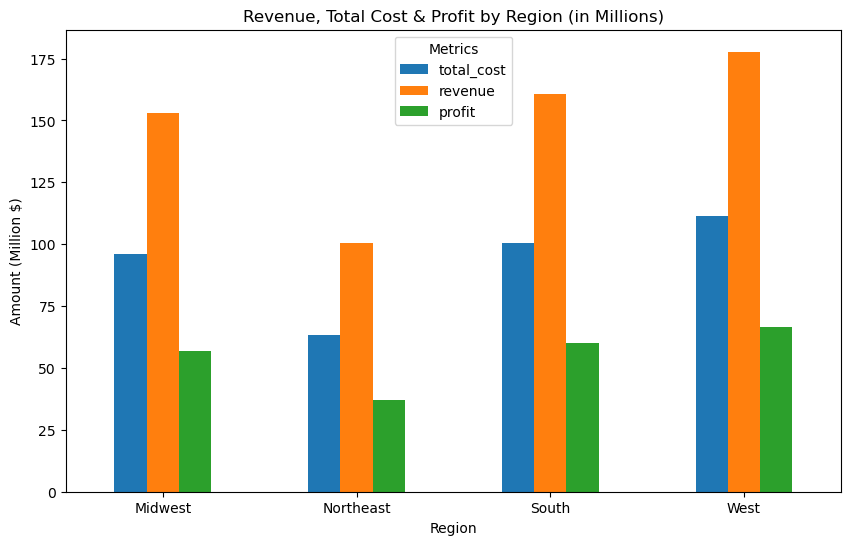

In [506]:
df_region_plot = df_region / 1_000_000

df_region_plot.plot(kind='bar', figsize=(10,6))
plt.title("Revenue, Total Cost & Profit by Region (in Millions)")
plt.ylabel("Amount (Million $)")
plt.xlabel("Region")
plt.xticks(rotation=0) 
plt.legend(title="Metrics")

plt.show()

#### we can say that top performing region is west > south > Midwest 

## State analysis

In [520]:
df_state = df2.groupby("state").agg(
           total_cost_state=("total_cost", "sum"), revenue_state=("line total", "sum"),
           profit_state=("profit", "sum")
       )

In [522]:
df_state = df_state.sort_values(by="profit_state", ascending=False) 

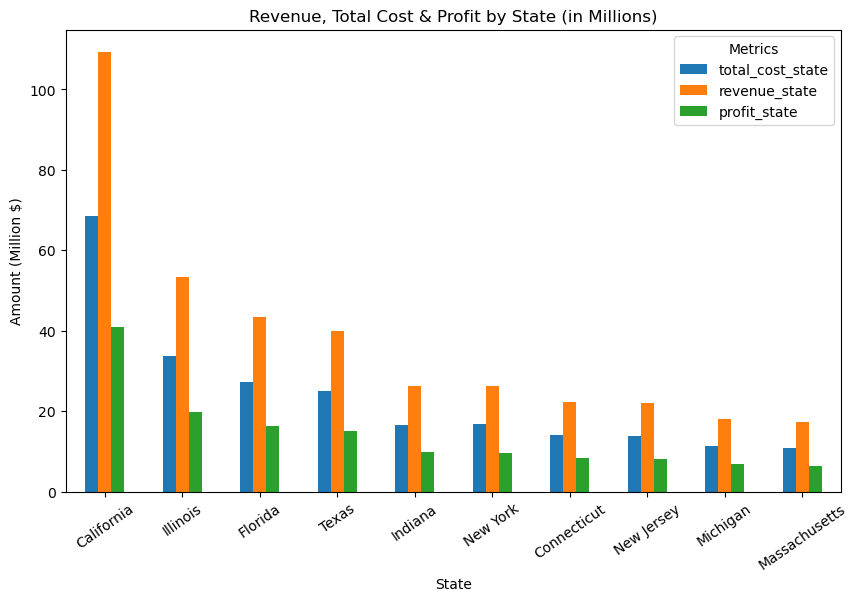

In [526]:
df_state_plot_top_10 = df_state.head(10) / 1_000_000

df_state_plot_top_10.plot(kind='bar', figsize=(10,6))
plt.title("Revenue, Total Cost & Profit by State (in Millions)")
plt.ylabel("Amount (Million $)")
plt.xlabel("State")
plt.xticks(rotation=35) 
plt.legend(title="Metrics")

plt.show()

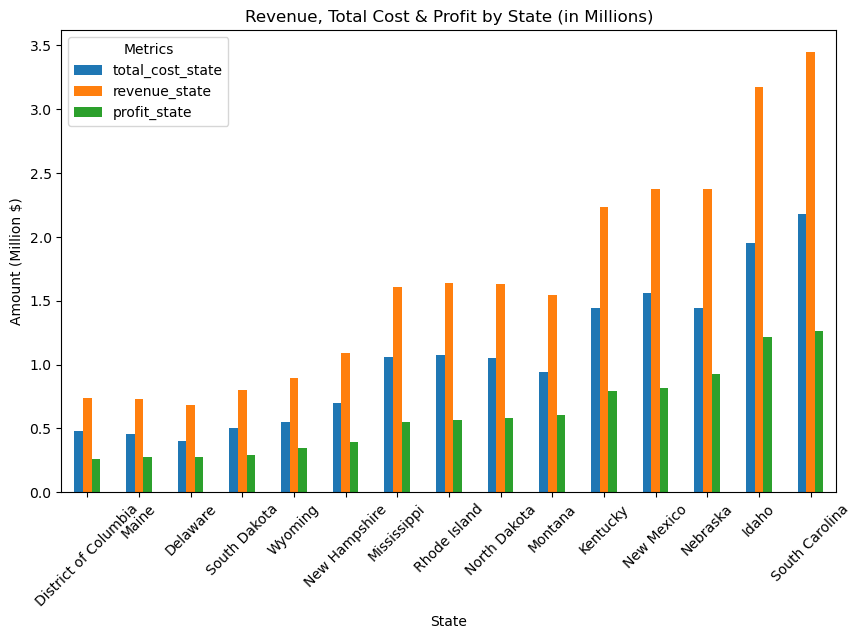

In [532]:
df_state_plot_low_10 = df_state.tail(15).sort_values(by="profit_state", ascending=True) / 1_000_000

df_state_plot_low_10.plot(kind='bar', figsize=(10,6))
plt.title("Revenue, Total Cost & Profit by State (in Millions)")
plt.ylabel("Amount (Million $)")
plt.xlabel("State")
plt.xticks(rotation=45) 
plt.legend(title="Metrics")

plt.show()

#### Every state has profit and the rate of total_cost per state is proportional to revenue and profit 

## Product Analysis

In [543]:
df_product = df2.groupby("product name").agg(
           total_cost_product=("total_cost", "sum"), revenue_product=("line total", "sum"),
           profit_product=("profit", "sum")
       )

In [545]:
df_product = df_product.sort_values(by="profit_product", ascending=False) 

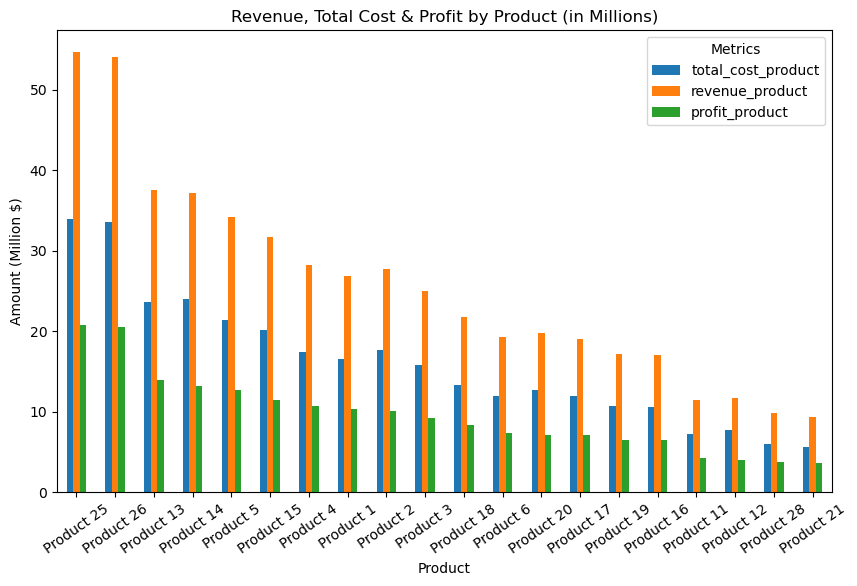

In [551]:
df_product_plot_top_20 = df_product.head(20) / 1_000_000

df_product_plot_top_20.plot(kind='bar', figsize=(10,6))
plt.title("Revenue, Total Cost & Profit by Product (in Millions)")
plt.ylabel("Amount (Million $)")
plt.xlabel("Product")
plt.xticks(rotation=35) 
plt.legend(title="Metrics")

plt.show()

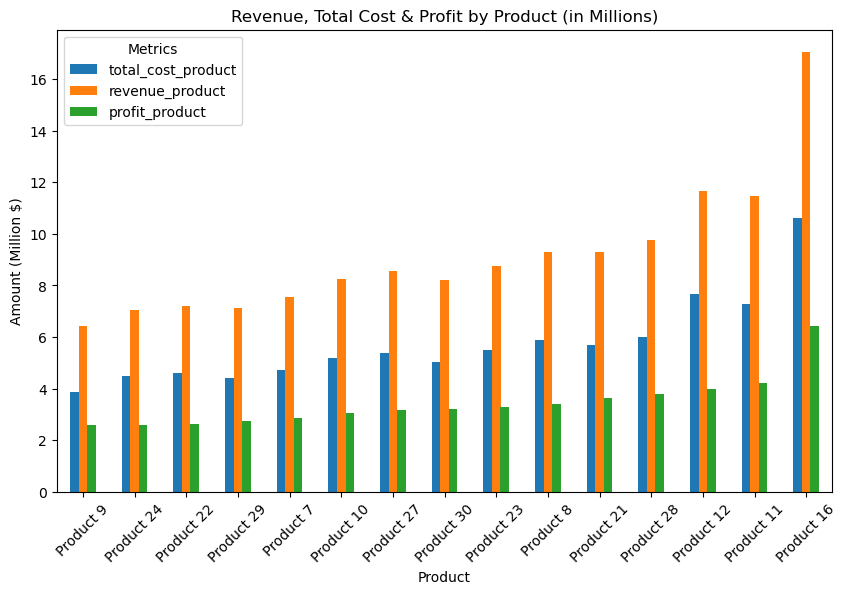

In [552]:
df_product_plot_low_10 = df_product.tail(15).sort_values(by="profit_product", ascending=True) / 1_000_000

df_product_plot_low_10.plot(kind='bar', figsize=(10,6))
plt.title("Revenue, Total Cost & Profit by Product (in Millions)")
plt.ylabel("Amount (Million $)")
plt.xlabel("Product")
plt.xticks(rotation=45) 
plt.legend(title="Metrics")

plt.show()

## Creating a csv file for power bi dashboard building 

In [539]:
df2.to_csv("Power BI csv.csv", index=False)